# Counterexample generator

**Goal:** Given a randomly generated true tree $T^*$, find an NNI neighbor $T$ and edge
distribution $\mathbf{p}$ such that $\bar C(T;\mathbf{p}) < \bar C(T^*;\mathbf{p})$.

In [49]:
# ── Analysis parameters ───────────────────────────────────────────────────────
ALPHA       = 0.20
BETA        = 0.01
N           = 10        # number of leaves
N_NEIGHBORS = 3         # NNI neighbors to generate and show
SEED        = 5

# Subset of neighbor indices (0-based) shown in the figure
SUBSET_IDX = [0, 1, 2]

# ── Output path ───────────────────────────────────────────────────────────────
FIGURE_PATH = "counterexample_generator.pdf"

In [50]:
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 150
from matplotlib.backends.backend_pdf import PdfPages

In [51]:
# Locate repo root and add src to path
cwd = Path.cwd()
src_candidates = [cwd / "src", cwd.parent / "src"]
SRC_DIR = next(p for p in src_candidates if (p / "inconsistency_generation").exists())
REPO_ROOT = SRC_DIR.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from inconsistency_generation.tree_generation import random_binary_tree_splits, random_nni
from inconsistency_generation.counterexample_analysis import make_nni_case, run_phase3
from inconsistency_generation.counterexample_plots import plot_nni_panel, plot_nni_subset
from inconsistency_generation.nni_delta_precomputation import default_flip_weights

W_P, W_N = default_flip_weights(ALPHA, BETA)

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
FIGURE_FILE = FIGURES_DIR / FIGURE_PATH

print(f"Seed: {SEED}")

Seed: 5


In [52]:
rng = np.random.default_rng(seed=SEED)

tree = random_binary_tree_splits(N, rng=rng)

neighbors = []
used_keys = set()
while len(neighbors) < N_NEIGHBORS:
    nbr, ek, ni, info = random_nni(tree, rng=rng)
    if ek not in used_keys:
        neighbors.append((nbr, ek, ni, info))
        used_keys.add(ek)

cases       = [make_nni_case(tree, nbr, ek, ALPHA, BETA, W_P, W_N) for nbr, ek, _, _ in neighbors]
all_results = [run_phase3(c) for c in cases]

for i, (c, res) in enumerate(zip(cases, all_results), 1):
    feasible = any(r[-1] for r in res if len(r) == 9)
    sign     = "  \u2190 inconsistent!" if c["diff_eq"] < 0 else ""
    print(f"NNI-{i} (edge '{c['edge_key']}'):  \u03a3 p\u0394 (equal) = {c['diff_eq']:+.6f}{sign}"
          f"  |  phase-3: {'feasible' if feasible else 'INFEASIBLE'}")

NNI-1 (edge 'int_2'):  Σ pΔ (equal) = +0.133846  |  phase-3: feasible
NNI-2 (edge 'int_1'):  Σ pΔ (equal) = +0.136572  |  phase-3: feasible
NNI-3 (edge 'int_6'):  Σ pΔ (equal) = +0.113727  |  phase-3: feasible


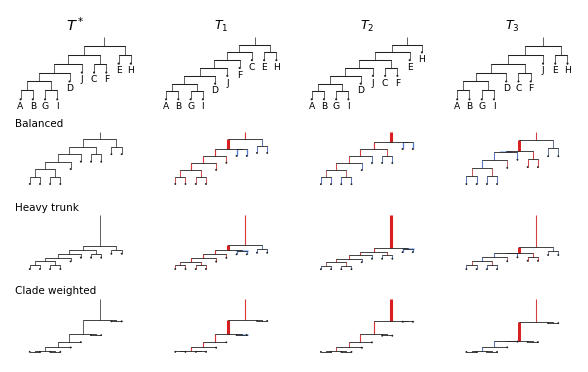

In [53]:
plot_nni_subset(cases, all_results, SUBSET_IDX, N, ALPHA, BETA, SEED)

In [54]:
with PdfPages(FIGURE_FILE) as pdf:
    plot_nni_subset(cases, all_results, SUBSET_IDX, N, ALPHA, BETA, SEED, pdf=pdf, show=False)
print(f"Saved {FIGURE_FILE}")

Saved /Users/satasg/Documents/repos/inconsistency_repo/figures/counterexample_generator.pdf
